In [2]:
!pip -q install \
    "datasets[audio]==3.6.0" \
    "librosa==0.11.0" \
    "soundfile==0.13.1" \
    "scikit-learn==1.6.1" \
    "seaborn==0.13.2" \
    "tqdm==4.67.1" \
    "joblib==1.4.2"

# Importing libraries

In [3]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "42"
os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
    if hf_token:
        os.environ["HF_TOKEN"] = hf_token
        os.environ["HUGGINGFACE_HUB_TOKEN"] = hf_token
except Exception:
    pass

import sys
import platform
import warnings
warnings.filterwarnings("ignore", message=".*unauthenticated.*")
warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")
warnings.filterwarnings("ignore", message=".*authentication.*")

import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import soundfile as sf

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetV2B0

from datasets import load_dataset, Audio

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

from tqdm.auto import tqdm
import joblib

print("Python:", sys.version)
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("librosa:", librosa.__version__)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU enabled:", gpus)
else:
    print("GPU not detected. Runtime > Change runtime type > GPU is recommended.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
TensorFlow: 2.20.0
NumPy: 2.0.2
librosa: 0.11.0
GPU enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Central Configuration

In [4]:
class CFG:
    DATASET_ID = "sanchit-gandhi/gtzan"
    SEED = 42

    SAMPLE_RATE = 22_050
    SR = SAMPLE_RATE
    TRACK_SECONDS = 30
    TRACK_SAMPLES = SAMPLE_RATE * TRACK_SECONDS

    SEGMENT_SECONDS = 3.0
    SEGMENT_HOP_SECONDS = 1.5
    SEGMENT_SAMPLES = int(SAMPLE_RATE * SEGMENT_SECONDS)
    SEGMENT_HOP_SAMPLES = int(SAMPLE_RATE * SEGMENT_HOP_SECONDS)

    N_FFT = 2048
    HOP_LENGTH = 512
    N_MELS = 128
    FMIN = 20
    FMAX = 11_025

    IMG_H = 128
    IMG_W = 128
    IMG_C = 1

    TEST_SIZE = 0.15
    VAL_SIZE = 0.15

    BATCH_SIZE = 32
    AUTOTUNE = tf.data.AUTOTUNE

    HEAD_LR = 3e-4
    FINE_TUNE_LR = 1e-5
    HEAD_EPOCHS = 40
    FINE_TUNE_EPOCHS = 40
    HEAD_PATIENCE = 10
    FINE_TUNE_PATIENCE = 12

    DROPOUT = 0.45
    L2 = 1e-4

    BEST_MODEL_PATH = "best_gtzan_efficientnetv2b0.keras"
    RF_MODEL_PATH = "gtzan_random_forest.joblib"

def seed_everything(seed: int = CFG.SEED) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

seed_everything(CFG.SEED)

def stable_track_id(audio: np.ndarray, label: int, idx: int) -> str:
    h = hashlib.sha256()
    h.update(np.asarray(audio[: min(len(audio), CFG.SAMPLE_RATE)], dtype=np.float32).tobytes())
    h.update(str(label).encode("utf-8"))
    h.update(str(idx).encode("utf-8"))
    return h.hexdigest()[:16]

print("Configuration loaded and RNGs seeded.")

Configuration loaded and RNGs seeded.


# Raw Hugging Face GTZAN Dataset Ingestion

In [6]:
raw_ds = load_dataset(CFG.DATASET_ID, split="train", streaming=False)
raw_ds = raw_ds.cast_column("audio", Audio(sampling_rate=CFG.SAMPLE_RATE))

GENRE_NAMES = raw_ds.features["genre"].names
NUM_CLASSES = len(GENRE_NAMES)

tracks = []
labels = []
track_ids = []

for idx, ex in enumerate(tqdm(raw_ds, desc="Materializing GTZAN tracks")):
    audio = np.asarray(ex["audio"]["array"], dtype=np.float32)
    label = int(ex["genre"])

    if len(audio) >= CFG.TRACK_SAMPLES:
        audio = audio[: CFG.TRACK_SAMPLES]
    else:
        audio = np.pad(audio, (0, CFG.TRACK_SAMPLES - len(audio)), mode="constant")

    tracks.append(audio.astype(np.float32))
    labels.append(label)
    track_ids.append(stable_track_id(audio, label, idx))

tracks = np.stack(tracks).astype(np.float32)
labels = np.asarray(labels, dtype=np.int64)
track_ids = np.asarray(track_ids)

print("Tracks:", tracks.shape)
print("Labels:", labels.shape)
print("Genres:", GENRE_NAMES)
print(pd.Series(labels).map(lambda i: GENRE_NAMES[i]).value_counts().sort_index())

Materializing GTZAN tracks:   0%|          | 0/999 [00:00<?, ?it/s]

Tracks: (999, 661500)
Labels: (999,)
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz          99
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


# Modular Exploratory Data Analysis Loop

Class Distribution

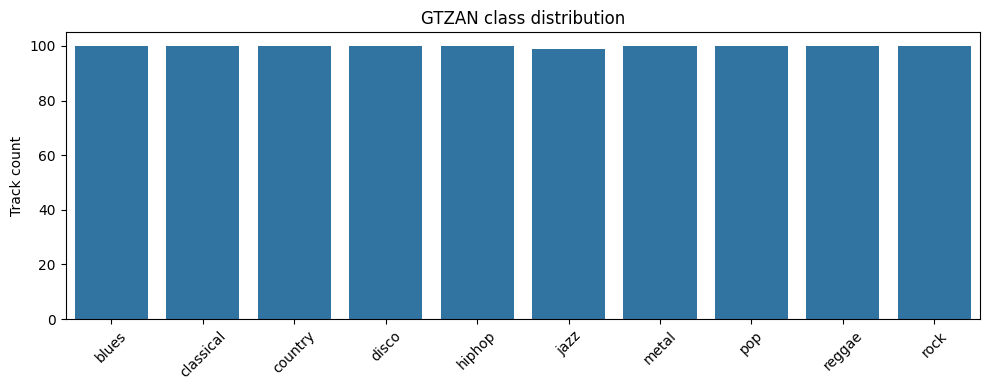

In [7]:
def plot_class_distribution(labels_arr: np.ndarray) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    counts = pd.Series(labels_arr).value_counts().sort_index()
    sns.barplot(x=[GENRE_NAMES[i] for i in counts.index], y=counts.values, ax=ax)
    ax.set_title("GTZAN class distribution")
    ax.set_ylabel("Track count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

plot_class_distribution(labels)

Waveform, Spectrogram, and Log-Mel

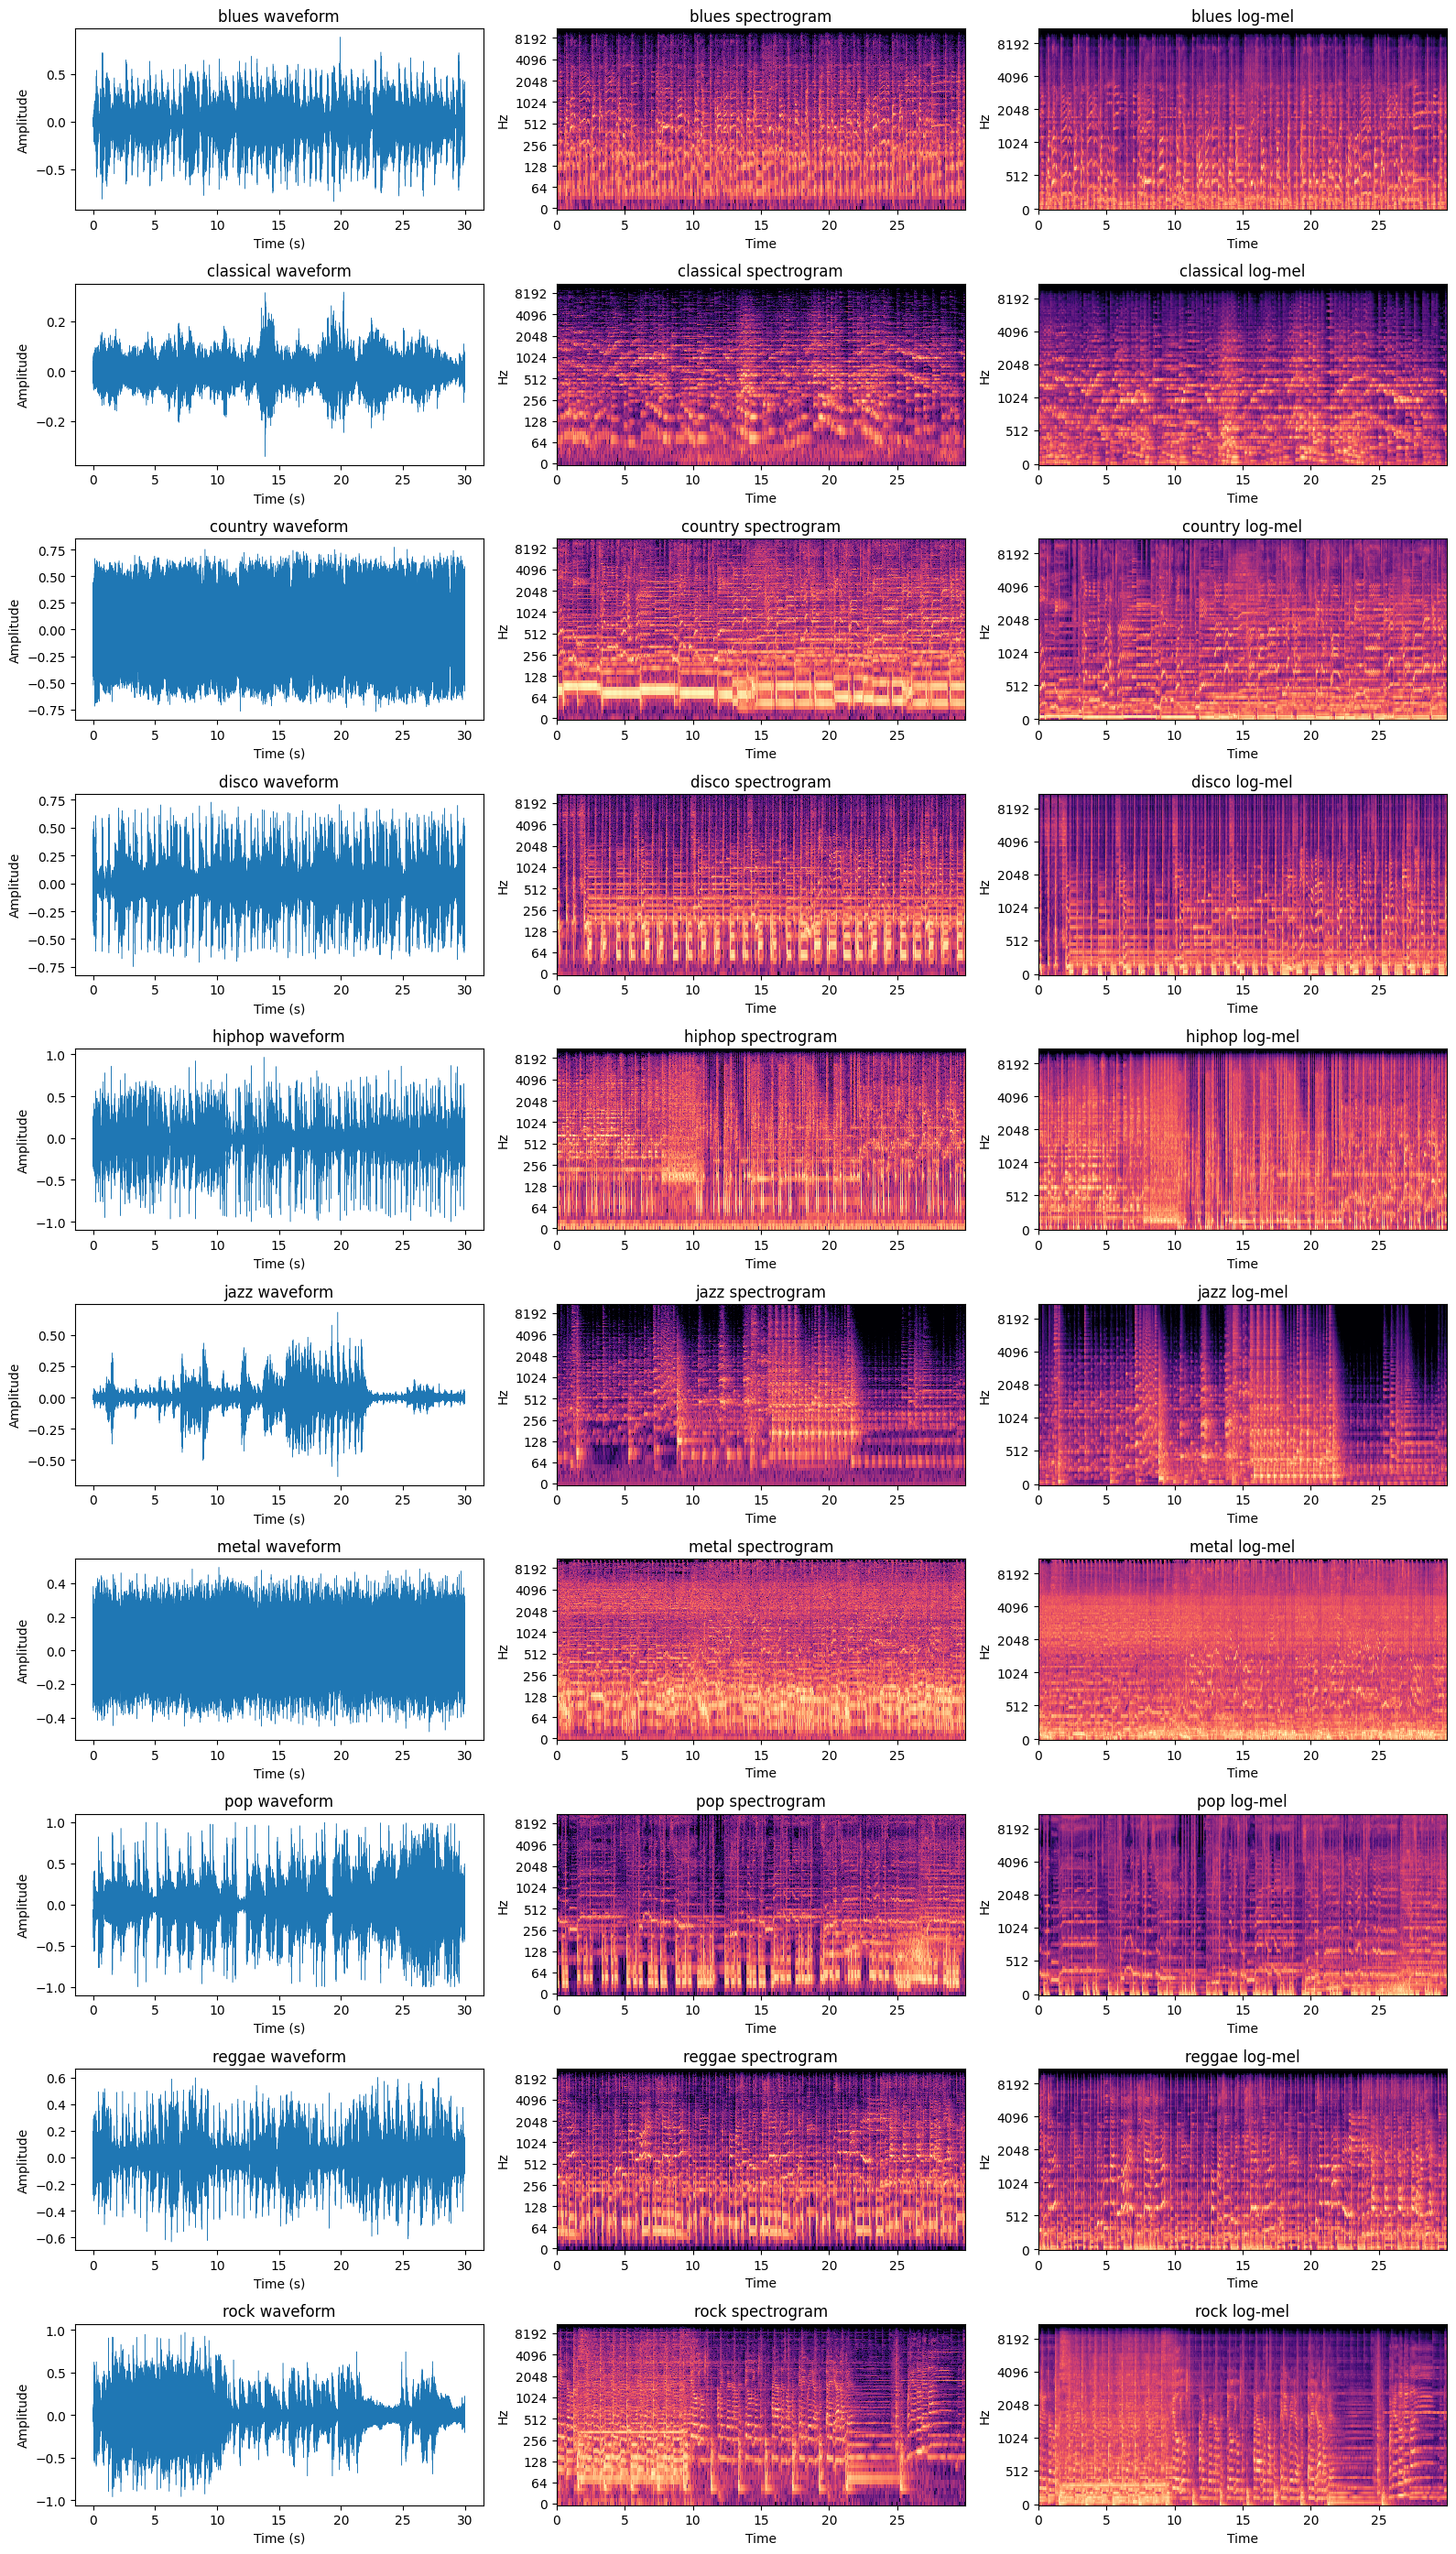

In [8]:
def plot_track_diagnostics(audio: np.ndarray, sr: int, genre: str, ax_wave, ax_spec, ax_mel) -> None:
    t = np.arange(len(audio)) / sr
    ax_wave.plot(t, audio, linewidth=0.35)
    ax_wave.set_title(f"{genre} waveform")
    ax_wave.set_xlabel("Time (s)")
    ax_wave.set_ylabel("Amplitude")

    stft = librosa.stft(audio, n_fft=CFG.N_FFT, hop_length=CFG.HOP_LENGTH)
    db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
    librosa.display.specshow(
        db,
        sr=CFG.SAMPLE_RATE,
        hop_length=CFG.HOP_LENGTH,
        x_axis="time",
        y_axis="log",
        ax=ax_spec,
    )
    ax_spec.set_title(f"{genre} spectrogram")

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=CFG.SAMPLE_RATE,
        n_fft=CFG.N_FFT,
        hop_length=CFG.HOP_LENGTH,
        n_mels=CFG.N_MELS,
        fmin=CFG.FMIN,
        fmax=CFG.FMAX,
        power=2.0,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(
        mel_db,
        sr=CFG.SAMPLE_RATE,
        hop_length=CFG.HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=ax_mel,
    )
    ax_mel.set_title(f"{genre} log-mel")

def plot_audio_visualizations(tracks_arr: np.ndarray, labels_arr: np.ndarray) -> None:
    chosen = []
    for cls in range(NUM_CLASSES):
        cls_indices = np.where(labels_arr == cls)[0]
        if len(cls_indices) > 0:
            chosen.append(cls_indices[0])

    fig, axes = plt.subplots(len(chosen), 3, figsize=(16, 2.8 * len(chosen)))
    if len(chosen) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(chosen):
        plot_track_diagnostics(
            tracks_arr[idx],
            CFG.SAMPLE_RATE,
            GENRE_NAMES[int(labels_arr[idx])],
            axes[row, 0],
            axes[row, 1],
            axes[row, 2],
        )

    plt.tight_layout()
    plt.show()

plot_audio_visualizations(tracks, labels)

# Duplicate Audit & Track-Level Split

In [9]:
track_hashes = np.asarray([
    hashlib.sha256(np.asarray(audio, dtype=np.float32).tobytes()).hexdigest()
    for audio in tracks
])

hash_counts = pd.Series(track_hashes).value_counts()
duplicate_hashes = hash_counts[hash_counts > 1]

print("Exact duplicate audio hashes:", len(duplicate_hashes))

duplicate_report = []
for h in duplicate_hashes.index:
    idxs = np.where(track_hashes == h)[0].tolist()
    duplicate_report.append(
        {
            "hash": h,
            "indices": idxs,
            "labels": [GENRE_NAMES[int(labels[i])] for i in idxs],
        }
    )

if duplicate_report:
    display(pd.DataFrame(duplicate_report))

group_df = (
    pd.DataFrame(
        {
            "track_index": np.arange(len(labels)),
            "hash": track_hashes,
            "label": labels,
        }
    )
    .groupby("hash")
    .agg(
        track_indices=("track_index", list),
        label_nunique=("label", "nunique"),
        label=("label", "first"),
        group_size=("track_index", "size"),
    )
    .reset_index()
)

mixed_label_groups = group_df[group_df["label_nunique"] > 1]
if len(mixed_label_groups) > 0:
    print(f"Warning: Found {len(mixed_label_groups)} duplicate audio groups with conflicting genres. Dropping them to preserve data integrity.")
    group_df = group_df[group_df["label_nunique"] == 1].reset_index(drop=True)

group_ids = np.arange(len(group_df))
group_labels = group_df["label"].to_numpy()

group_train, group_temp = train_test_split(
    group_ids,
    test_size=CFG.TEST_SIZE + CFG.VAL_SIZE,
    random_state=CFG.SEED,
    stratify=group_labels,
)

relative_test_size = CFG.TEST_SIZE / (CFG.TEST_SIZE + CFG.VAL_SIZE)

group_val, group_test = train_test_split(
    group_temp,
    test_size=relative_test_size,
    random_state=CFG.SEED,
    stratify=group_labels[group_temp],
)

def expand_group_indices(group_selection: np.ndarray) -> np.ndarray:
    indices = []
    for group_id in group_selection:
        indices.extend(group_df.loc[int(group_id), "track_indices"])
    return np.asarray(sorted(indices), dtype=np.int64)

train_idx = expand_group_indices(group_train)
val_idx = expand_group_indices(group_val)
test_idx = expand_group_indices(group_test)

assert set(train_idx).isdisjoint(set(val_idx))
assert set(train_idx).isdisjoint(set(test_idx))
assert set(val_idx).isdisjoint(set(test_idx))

assert set(track_hashes[train_idx]).isdisjoint(set(track_hashes[val_idx]))
assert set(track_hashes[train_idx]).isdisjoint(set(track_hashes[test_idx]))
assert set(track_hashes[val_idx]).isdisjoint(set(track_hashes[test_idx]))

def summarize_split(name: str, idx: np.ndarray) -> pd.Series:
    s = pd.Series(labels[idx]).value_counts().sort_index()
    print(f"{name}: {len(idx)} tracks")
    print(pd.DataFrame({"genre": [GENRE_NAMES[i] for i in s.index], "count": s.values}))
    return s

train_counts = summarize_split("train", train_idx)
val_counts = summarize_split("validation", val_idx)
test_counts = summarize_split("test", test_idx)

print("Duplicate-group-aware split complete.")

Exact duplicate audio hashes: 14


,hash,indices,labels
0,ced9e51a3abc1f9b8d1527cb64bc1fd4423238c0e2999a...,"[766, 770]","[pop, pop]"
1,d9f975a7b333a7e6cb39c72cd58276bbeec5767b03a21d...,"[476, 478]","[hiphop, hiphop]"
2,15da762824d28958731b2738a4941dde585fa24018a2f8...,"[398, 399]","[disco, disco]"
3,0bb17da6b462352e6ec62603d7e52a3dedd66b83248bed...,"[657, 915]","[metal, rock]"
4,3b38af570039799cfb10465dbf38df9c83318e646574d1...,"[753, 759]","[pop, pop]"
5,98c435fdbf8a6ee992290181df1ef6ce3c71144dd37faa...,"[633, 693]","[metal, metal]"
6,8e1ce63b59ea0e5e997bdcbbe5fbc53de9a311b10f18ad...,"[644, 665]","[metal, metal]"
7,dae920e3397f8b40cb3e59942fd375901bb044ded7fa5f...,"[643, 664]","[metal, metal]"
8,2fc370aeacd3a1f1b265584a57fc1a00d97ac436a9b85c...,"[880, 881]","[reggae, reggae]"
9,9d4090e55aff12c7d4ff48a8e9e5fbb9a91ceae3d898a3...,"[439, 445]","[hiphop, hiphop]"


train: 699 tracks
       genre  count
0      blues     70
1  classical     70
2    country     70
3      disco     70
4     hiphop     71
5       jazz     69
6      metal     71
7        pop     69
8     reggae     70
9       rock     69
validation: 149 tracks
       genre  count
0      blues     15
1  classical     15
2    country     15
3      disco     15
4     hiphop     14
5       jazz     15
6      metal     14
7        pop     16
8     reggae     15
9       rock     15
test: 149 tracks
       genre  count
0      blues     15
1  classical     15
2    country     15
3      disco     15
4     hiphop     15
5       jazz     15
6      metal     14
7        pop     15
8     reggae     15
9       rock     15
Duplicate-group-aware split complete.


# Track-To-Segment Logic With 3-Second Overlapping Windows

In [10]:
def safe_audio_to_logmel(segment: np.ndarray) -> np.ndarray:
    segment = np.asarray(segment, dtype=np.float32).ravel()

    if segment.size == 0:
        segment = np.zeros(CFG.SEGMENT_SAMPLES, dtype=np.float32)

    if segment.size < CFG.SEGMENT_SAMPLES:
        segment = np.pad(segment, (0, CFG.SEGMENT_SAMPLES - segment.size), mode="constant")
    elif segment.size > CFG.SEGMENT_SAMPLES:
        segment = segment[: CFG.SEGMENT_SAMPLES]

    mel = librosa.feature.melspectrogram(
        y=segment,
        sr=CFG.SAMPLE_RATE,
        n_fft=CFG.N_FFT,
        hop_length=CFG.HOP_LENGTH,
        n_mels=CFG.N_MELS,
        fmin=CFG.FMIN,
        fmax=CFG.FMAX,
        power=2.0,
    ).astype(np.float32)

    mel = np.maximum(mel, 1e-8)

    logmel = librosa.power_to_db(
        mel,
        ref=np.max,
        amin=1e-8,
        top_db=80.0,
    ).astype(np.float32)

    logmel = np.nan_to_num(logmel, nan=-80.0, posinf=0.0, neginf=-80.0)
    logmel = np.clip(logmel, -80.0, 0.0)

    logmel = tf.image.resize(
        logmel[..., None],
        [CFG.IMG_H, CFG.IMG_W],
        method="bilinear",
        antialias=True,
    ).numpy()

    logmel = np.nan_to_num(logmel, nan=-80.0, posinf=0.0, neginf=-80.0)
    logmel = np.clip(logmel, -80.0, 0.0)

    return logmel.astype(np.float32)

SEGMENT_STARTS = np.arange(
    0,
    CFG.TRACK_SAMPLES - CFG.SEGMENT_SAMPLES + 1,
    CFG.SEGMENT_HOP_SAMPLES,
    dtype=np.int64,
)
print("Segment windows per track:", len(SEGMENT_STARTS))

def build_safe_spectrogram_split(split_name: str, indices: np.ndarray):
    indices = np.asarray(indices, dtype=np.int64)

    if indices.ndim != 1 or indices.size == 0:
        raise ValueError(f"{split_name} indices must be a non-empty 1D array.")

    n_segments = len(indices) * len(SEGMENT_STARTS)
    X = np.empty((n_segments, CFG.IMG_H, CFG.IMG_W, 1), dtype=np.float32)
    y = np.empty((n_segments,), dtype=np.int64)
    segment_track_idx = np.empty((n_segments,), dtype=np.int64)
    segment_track_ids = np.empty((n_segments,), dtype=object)

    write_idx = 0

    for track_index in tqdm(indices, desc=f"Building {split_name} safe log-mel spectrograms"):
        track_index = int(track_index)
        audio = np.asarray(tracks[track_index], dtype=np.float32).ravel()
        label = int(labels[track_index])
        track_id = track_ids[track_index]

        if audio.size < CFG.TRACK_SAMPLES:
            audio = np.pad(audio, (0, CFG.TRACK_SAMPLES - audio.size), mode="constant")
        elif audio.size > CFG.TRACK_SAMPLES:
            audio = audio[: CFG.TRACK_SAMPLES]

        for start in SEGMENT_STARTS:
            start = int(start)
            end = start + CFG.SEGMENT_SAMPLES
            X[write_idx] = safe_audio_to_logmel(audio[start:end])
            y[write_idx] = label
            segment_track_idx[write_idx] = track_index
            segment_track_ids[write_idx] = track_id
            write_idx += 1

    X = X[:write_idx]
    y = y[:write_idx]
    segment_track_idx = segment_track_idx[:write_idx]
    segment_track_ids = segment_track_ids[:write_idx]

    if not np.isfinite(X).all():
        raise FloatingPointError(f"{split_name} spectrograms contain non-finite values after safe conversion.")

    return X, y, segment_track_idx, segment_track_ids

X_train_spec, y_train_seg, train_seg_track_idx, train_seg_track_ids = build_safe_spectrogram_split("train", train_idx)
X_val_spec, y_val_seg, val_seg_track_idx, val_seg_track_ids = build_safe_spectrogram_split("validation", val_idx)
X_test_spec, y_test_seg, test_seg_track_idx, test_seg_track_ids = build_safe_spectrogram_split("test", test_idx)

print("Train spectrograms:", X_train_spec.shape, X_train_spec.dtype, float(X_train_spec.min()), float(X_train_spec.max()))
print("Validation spectrograms:", X_val_spec.shape, X_val_spec.dtype, float(X_val_spec.min()), float(X_val_spec.max()))
print("Test spectrograms:", X_test_spec.shape, X_test_spec.dtype, float(X_test_spec.min()), float(X_test_spec.max()))

Segment windows per track: 19


Building train safe log-mel spectrograms:   0%|          | 0/699 [00:00<?, ?it/s]

Building validation safe log-mel spectrograms:   0%|          | 0/149 [00:00<?, ?it/s]

Building test safe log-mel spectrograms:   0%|          | 0/149 [00:00<?, ?it/s]

Train spectrograms: (13281, 128, 128, 1) float32 -80.0 -3.659366484498605e-05
Validation spectrograms: (2831, 128, 128, 1) float32 -80.0 -1.1790882126661018e-05
Test spectrograms: (2831, 128, 128, 1) float32 -80.0 -7.167011790443212e-05


# Global Training-Set Normalization Statistics And Universal Application

In [11]:
X_train_float = X_train_spec.astype(np.float32, copy=False)

if not np.isfinite(X_train_float).all():
    raise FloatingPointError("Training spectrograms contain non-finite values before normalization.")

SPEC_MEAN = float(np.mean(X_train_float, dtype=np.float64))
SPEC_STD = float(np.std(X_train_float, dtype=np.float64))

if not np.isfinite(SPEC_MEAN):
    raise FloatingPointError(f"Invalid spectrogram mean: {SPEC_MEAN}")

if not np.isfinite(SPEC_STD) or SPEC_STD <= 1e-6:
    raise FloatingPointError(f"Invalid spectrogram std: {SPEC_STD}")

def normalize_spectrogram_array(X: np.ndarray, split_name: str) -> np.ndarray:
    X = X.astype(np.float32, copy=False)

    if not np.isfinite(X).all():
        raise FloatingPointError(f"{split_name} spectrograms contain non-finite values before normalization.")

    X_norm = (X - SPEC_MEAN) / SPEC_STD
    X_norm = np.nan_to_num(X_norm, nan=0.0, posinf=0.0, neginf=0.0)
    X_norm = np.clip(X_norm, -5.0, 5.0)

    if not np.isfinite(X_norm).all():
        raise FloatingPointError(f"{split_name} spectrograms contain non-finite values after normalization.")

    if float(np.std(X_norm, dtype=np.float64)) <= 1e-8:
        raise FloatingPointError(f"{split_name} spectrograms collapsed to near-constant values after normalization.")

    return X_norm.astype(np.float16)

X_train_spec = normalize_spectrogram_array(X_train_spec, "train")
X_val_spec = normalize_spectrogram_array(X_val_spec, "validation")
X_test_spec = normalize_spectrogram_array(X_test_spec, "test")

print("Global train-only spectrogram normalization stats:")
print("SPEC_MEAN:", SPEC_MEAN)
print("SPEC_STD:", SPEC_STD)

print("Post-normalization train mean/std:", float(np.mean(X_train_spec.astype(np.float32))), float(np.std(X_train_spec.astype(np.float32))))
print("Post-normalization validation mean/std:", float(np.mean(X_val_spec.astype(np.float32))), float(np.std(X_val_spec.astype(np.float32))))
print("Post-normalization test mean/std:", float(np.mean(X_test_spec.astype(np.float32))), float(np.std(X_test_spec.astype(np.float32))))

Global train-only spectrogram normalization stats:
SPEC_MEAN: -40.555237167304924
SPEC_STD: 15.257082807858762
Post-normalization train mean/std: -1.2615711966645904e-05 1.000033974647522
Post-normalization validation mean/std: 0.027951357886195183 0.9647887945175171
Post-normalization test mean/std: -0.022905705496668816 0.9852215647697449


# The Spectrogram Guard

In [12]:
required_specs = ["X_train_spec", "X_val_spec", "X_test_spec"]
missing_specs = [name for name in required_specs if name not in globals()]

if missing_specs:
    raise NameError(
        f"Missing spectrogram tensors: {missing_specs}. "
        "Run the safe segmentation/log-mel generation cell first."
    )

for name in required_specs:
    X = globals()[name]
    if not np.isfinite(X).all():
        raise FloatingPointError(f"{name} contains non-finite values.")
    if np.std(X.astype(np.float32)) <= 1e-8:
        raise FloatingPointError(f"{name} has collapsed variance.")

print("Safe spectrogram tensors are present and numerically valid.")

Safe spectrogram tensors are present and numerically valid.


# Robust Track-Level Tabular Feature Extraction With Exact Feature Name Mapping


In [13]:
def _safe_track_audio(audio: np.ndarray) -> np.ndarray:
    audio = np.asarray(audio, dtype=np.float32).ravel()

    if audio.size == 0:
        audio = np.zeros(CFG.TRACK_SAMPLES, dtype=np.float32)

    if audio.size < CFG.TRACK_SAMPLES:
        audio = np.pad(audio, (0, CFG.TRACK_SAMPLES - audio.size), mode="constant")
    elif audio.size > CFG.TRACK_SAMPLES:
        audio = audio[: CFG.TRACK_SAMPLES]

    audio = np.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return audio

def _append_stats(values: np.ndarray, prefix: str, feats: list, names: list) -> None:
    values = np.asarray(values, dtype=np.float32).ravel()
    values = values[np.isfinite(values)]

    if values.size == 0:
        values = np.asarray([0.0], dtype=np.float32)

    stat_pairs = [
        ("mean", float(np.mean(values))),
        ("std", float(np.std(values))),
        ("var", float(np.var(values))),
        ("median", float(np.median(values))),
        ("min", float(np.min(values))),
        ("max", float(np.max(values))),
        ("p10", float(np.percentile(values, 10))),
        ("p25", float(np.percentile(values, 25))),
        ("p75", float(np.percentile(values, 75))),
        ("p90", float(np.percentile(values, 90))),
    ]

    for stat_name, stat_value in stat_pairs:
        names.append(f"{prefix}_{stat_name}")
        feats.append(stat_value)

def extract_track_level_features(audio: np.ndarray):
    feats = []
    names = []
    audio = _safe_track_audio(audio)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=CFG.SAMPLE_RATE,
        n_mfcc=20,
        n_fft=CFG.N_FFT,
        hop_length=CFG.HOP_LENGTH,
    ).astype(np.float32)

    mfcc_delta = librosa.feature.delta(mfcc).astype(np.float32)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2).astype(np.float32)

    for family_name, matrix in [
        ("mfcc", mfcc),
        ("mfcc_delta", mfcc_delta),
        ("mfcc_delta2", mfcc_delta2),
    ]:
        for i in range(matrix.shape[0]):
            _append_stats(matrix[i], f"{family_name}_{i + 1:02d}", feats, names)

    chroma = librosa.feature.chroma_stft(
        y=audio,
        sr=CFG.SAMPLE_RATE,
        n_fft=CFG.N_FFT,
        hop_length=CFG.HOP_LENGTH,
    ).astype(np.float32)
    for i in range(chroma.shape[0]):
        _append_stats(chroma[i], f"chroma_{i + 1:02d}", feats, names)

    contrast = librosa.feature.spectral_contrast(
        y=audio,
        sr=CFG.SAMPLE_RATE,
        n_fft=CFG.N_FFT,
        hop_length=CFG.HOP_LENGTH,
    ).astype(np.float32)
    for i in range(contrast.shape[0]):
        _append_stats(contrast[i], f"spectral_contrast_{i + 1:02d}", feats, names)

    tonnetz = librosa.feature.tonnetz(
        y=librosa.effects.harmonic(audio),
        sr=CFG.SAMPLE_RATE,
    ).astype(np.float32)
    for i in range(tonnetz.shape[0]):
        _append_stats(tonnetz[i], f"tonnetz_{i + 1:02d}", feats, names)

    scalar_features = {
        "spectral_centroid": librosa.feature.spectral_centroid(
            y=audio,
            sr=CFG.SAMPLE_RATE,
            n_fft=CFG.N_FFT,
            hop_length=CFG.HOP_LENGTH,
        )[0],
        "spectral_bandwidth": librosa.feature.spectral_bandwidth(
            y=audio,
            sr=CFG.SAMPLE_RATE,
            n_fft=CFG.N_FFT,
            hop_length=CFG.HOP_LENGTH,
        )[0],
        "spectral_rolloff": librosa.feature.spectral_rolloff(
            y=audio,
            sr=CFG.SAMPLE_RATE,
            n_fft=CFG.N_FFT,
            hop_length=CFG.HOP_LENGTH,
        )[0],
        "spectral_flatness": librosa.feature.spectral_flatness(
            y=audio,
            n_fft=CFG.N_FFT,
            hop_length=CFG.HOP_LENGTH,
        )[0],
        "zero_crossing_rate": librosa.feature.zero_crossing_rate(
            y=audio,
            frame_length=CFG.N_FFT,
            hop_length=CFG.HOP_LENGTH,
        )[0],
        "rms": librosa.feature.rms(
            y=audio,
            frame_length=CFG.N_FFT,
            hop_length=CFG.HOP_LENGTH,
        )[0],
    }

    for feature_name, values in scalar_features.items():
        _append_stats(values, feature_name, feats, names)

    onset_env = librosa.onset.onset_strength(
        y=audio,
        sr=CFG.SAMPLE_RATE,
        hop_length=CFG.HOP_LENGTH,
    ).astype(np.float32)
    _append_stats(onset_env, "onset_strength", feats, names)

    try:
        tempo = librosa.feature.rhythm.tempo(
            onset_envelope=onset_env,
            sr=CFG.SAMPLE_RATE,
            hop_length=CFG.HOP_LENGTH,
        )
    except Exception:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            tempo = librosa.beat.tempo(
                onset_envelope=onset_env,
                sr=CFG.SAMPLE_RATE,
                hop_length=CFG.HOP_LENGTH,
            )

    names.append("tempo")
    feats.append(float(np.ravel(tempo)[0]))

    feats = np.asarray(feats, dtype=np.float32)
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    return feats, names

feature_rows = []
feature_names_ref = None

for track_audio in tqdm(tracks, desc="Extracting strict track-level RF features"):
    row, row_names = extract_track_level_features(track_audio)

    if feature_names_ref is None:
        feature_names_ref = list(row_names)
    elif list(row_names) != feature_names_ref:
        raise ValueError("Feature names are not aligned across tracks.")

    feature_rows.append(row)

X_tab = np.stack(feature_rows).astype(np.float32)
FEATURE_NAMES = list(feature_names_ref)

if X_tab.shape[0] != len(labels):
    raise ValueError(f"Track-level feature rows {X_tab.shape[0]} do not match labels {len(labels)}.")

if X_tab.shape[1] != len(FEATURE_NAMES):
    raise ValueError(f"Feature columns {X_tab.shape[1]} do not match feature names {len(FEATURE_NAMES)}.")

if len(FEATURE_NAMES) != len(set(FEATURE_NAMES)):
    raise ValueError("Duplicate feature names detected.")

if not np.isfinite(X_tab).all():
    raise FloatingPointError("Track-level tabular feature matrix contains non-finite values.")

print("Strict track-level RF feature matrix:", X_tab.shape)
print("Feature count:", len(FEATURE_NAMES))

Extracting strict track-level RF features:   0%|          | 0/999 [00:00<?, ?it/s]

Strict track-level RF feature matrix: (999, 921)
Feature count: 921


# Random Forest Baseline Training And Evaluation



In [14]:
rf_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        (
            "rf",
            RandomForestClassifier(
                random_state=CFG.SEED,
                class_weight="balanced_subsample",
                bootstrap=True,
            ),
        ),
    ]
)

rf_param_grid = {
    "rf__n_estimators": [300, 500],
    "rf__max_depth": [None, 24],
    "rf__min_samples_split": [2, 6],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt"],
}

rf_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=CFG.SEED,
)

rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="accuracy",
    cv=rf_cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

rf_search.fit(X_tab[train_idx], labels[train_idx])
rf_model = rf_search.best_estimator_

rf_val_pred = rf_model.predict(X_tab[val_idx])
rf_test_pred = rf_model.predict(X_tab[test_idx])

print("Best RF params:", rf_search.best_params_)
print("Best RF CV accuracy:", rf_search.best_score_)
print("RF validation accuracy:", accuracy_score(labels[val_idx], rf_val_pred))
print("RF test accuracy:", accuracy_score(labels[test_idx], rf_test_pred))
print(classification_report(labels[test_idx], rf_test_pred, target_names=GENRE_NAMES))

joblib.dump(
    {
        "model": rf_model,
        "feature_names": FEATURE_NAMES,
        "config": {
            "sample_rate": CFG.SAMPLE_RATE,
            "n_fft": CFG.N_FFT,
            "hop_length": CFG.HOP_LENGTH,
            "track_samples": CFG.TRACK_SAMPLES,
        },
    },
    CFG.RF_MODEL_PATH,
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best RF params: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 6, 'rf__n_estimators': 500}
Best RF CV accuracy: 0.7481808838643371
RF validation accuracy: 0.7516778523489933
RF test accuracy: 0.7516778523489933
              precision    recall  f1-score   support

       blues       0.75      0.80      0.77        15
   classical       1.00      1.00      1.00        15
     country       0.67      0.93      0.78        15
       disco       0.55      0.40      0.46        15
      hiphop       0.76      0.87      0.81        15
        jazz       0.88      0.93      0.90        15
       metal       0.85      0.79      0.81        14
         pop       0.83      0.67      0.74        15
      reggae       0.60      0.60      0.60        15
        rock       0.62      0.53      0.57        15

    accuracy                           0.75       149
   macro avg       0.

['gtzan_random_forest.joblib']

# Random Forest Permutation Feature Importance


In [15]:
rf_estimator = rf_model.named_steps["rf"] if hasattr(rf_model, "named_steps") and "rf" in rf_model.named_steps else rf_model

original_rf_n_jobs = getattr(rf_estimator, "n_jobs", None)
rf_estimator.n_jobs = 1

try:
    perm = permutation_importance(
        rf_model,
        X_tab[val_idx],
        labels[val_idx],
        n_repeats=5,
        random_state=CFG.SEED,
        n_jobs=-1,
        scoring="accuracy",
    )
finally:
    if original_rf_n_jobs is not None:
        rf_estimator.n_jobs = original_rf_n_jobs
    else:
        rf_estimator.n_jobs = -1

importance_df = (
    pd.DataFrame(
        {
            "feature": FEATURE_NAMES,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(30))

,feature,importance_mean,importance_std
0,spectral_contrast_05_mean,0.008054,0.005022
1,rms_max,0.008054,0.005022
2,rms_p90,0.006711,0.000000
3,tonnetz_04_min,0.006711,0.000000
4,tonnetz_02_std,0.006711,0.000000
5,tonnetz_01_p25,0.006711,0.000000
6,tonnetz_01_p10,0.006711,0.000000
7,tonnetz_01_min,0.006711,0.000000
8,tonnetz_01_median,0.006711,0.000000
9,mfcc_03_p90,0.006711,0.000000


# Permutation Feature Importance Visualization

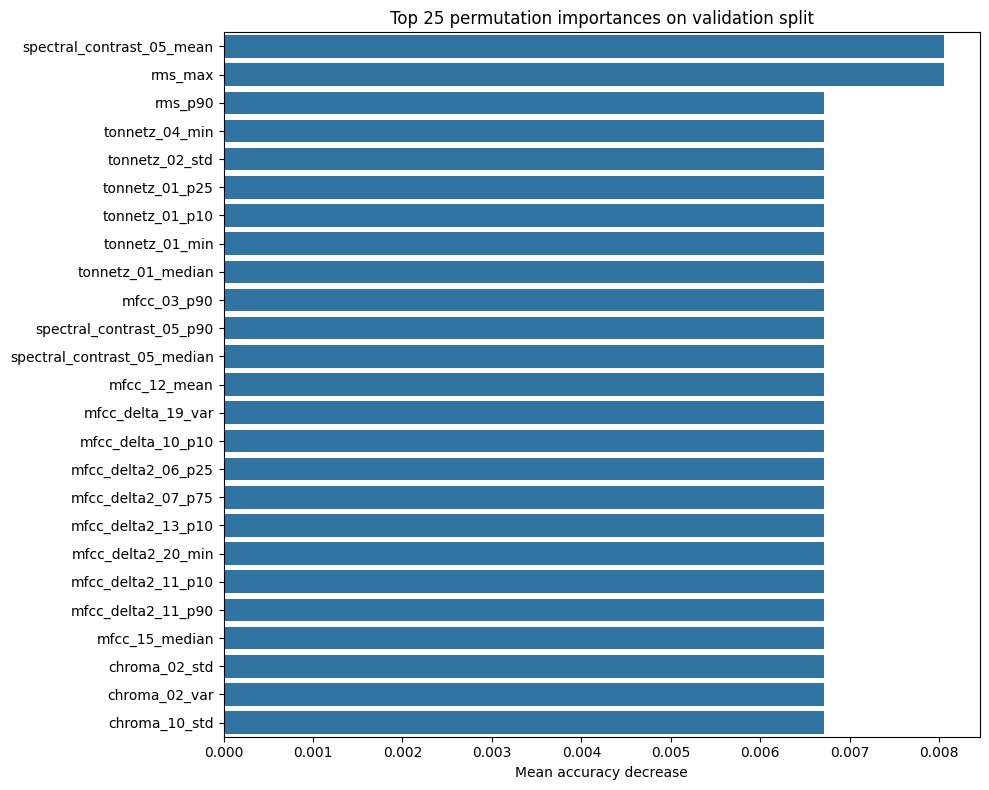

In [16]:
top_n = min(25, len(importance_df))
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(top_n),
    x="importance_mean",
    y="feature",
    orient="h",
)
plt.title(f"Top {top_n} permutation importances on validation split")
plt.xlabel("Mean accuracy decrease")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Data Integrity Check

In [18]:
assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0

assert set(train_seg_track_idx).issubset(set(train_idx))
assert set(val_seg_track_idx).issubset(set(val_idx))
assert set(test_seg_track_idx).issubset(set(test_idx))

assert set(train_seg_track_idx).isdisjoint(set(val_seg_track_idx))
assert set(train_seg_track_idx).isdisjoint(set(test_seg_track_idx))
assert set(val_seg_track_idx).isdisjoint(set(test_seg_track_idx))

assert np.isfinite(X_train_spec).all()
assert np.isfinite(X_val_spec).all()
assert np.isfinite(X_test_spec).all()

assert np.std(X_train_spec) > 1e-6
assert np.std(X_val_spec) > 1e-6
assert np.std(X_test_spec) > 1e-6

print("Leakage, finiteness, and variance checks passed.")

Leakage, finiteness, and variance checks passed.


# TensorFlow Dataset Materialization

In [19]:
def make_tf_dataset(X: np.ndarray, y: np.ndarray, training: bool = False) -> tf.data.Dataset:
    X = np.asarray(X)
    y = np.asarray(y, dtype=np.int64)

    if X.ndim != 4:
        raise ValueError(f"Expected X to be rank-4 [N, H, W, C], got shape {X.shape}.")

    if len(X) != len(y):
        raise ValueError(f"Feature/label length mismatch: {len(X)} != {len(y)}.")

    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    def preprocess_for_model(spec, label):
        spec = tf.cast(spec, tf.float32)
        label = tf.cast(label, tf.int32)

        if tf.shape(spec)[-1] != 1:
            spec = spec[..., :1]

        return spec, label

    dataset = dataset.map(preprocess_for_model, num_parallel_calls=CFG.AUTOTUNE)

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(y), 4096),
            seed=CFG.SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.batch(CFG.BATCH_SIZE, drop_remainder=False)
    dataset = dataset.prefetch(CFG.AUTOTUNE)

    return dataset

train_ds = make_tf_dataset(X_train_spec, y_train_seg, training=True)
val_ds = make_tf_dataset(X_val_spec, y_val_seg, training=False)
test_ds = make_tf_dataset(X_test_spec, y_test_seg, training=False)

for batch_x, batch_y in train_ds.take(1):
    print("Train batch X:", batch_x.shape, batch_x.dtype)
    print("Train batch y:", batch_y.shape, batch_y.dtype)

print("train_ds, val_ds, and test_ds are ready.")

Train batch X: (32, 128, 128, 1) <dtype: 'float32'>
Train batch y: (32,) <dtype: 'int32'>
train_ds, val_ds, and test_ds are ready.


# Deep Learning Architecture With EfficientNetV2B0

In [20]:
@keras.utils.register_keras_serializable(package="GTZAN")
class ClipToRange(layers.Layer):
    def __init__(self, min_value=-1.0, max_value=1.0, **kwargs):
        super().__init__(**kwargs)
        self.min_value = min_value
        self.max_value = max_value

    def call(self, inputs):
        return tf.clip_by_value(inputs, self.min_value, self.max_value)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "min_value": self.min_value,
                "max_value": self.max_value,
            }
        )
        return config

base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    include_preprocessing=False,
    input_shape=(CFG.IMG_H, CFG.IMG_W, 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(CFG.IMG_H, CFG.IMG_W, 1), name="logmel_input")
x = layers.Concatenate(name="grayscale_to_rgb")([inputs, inputs, inputs])
x = layers.Rescaling(scale=1.0 / 5.0, name="standardized_range_rescale")(x)
x = ClipToRange(-1.0, 1.0, name="clip_to_efficientnet_range")(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.BatchNormalization(name="head_batchnorm")(x)
x = layers.Dropout(CFG.DROPOUT, name="head_dropout_1")(x)
x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=regularizers.l2(CFG.L2),
    name="head_dense",
)(x)
x = layers.Dropout(CFG.DROPOUT, name="head_dropout_2")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="genre_classifier")(x)

dl_model = keras.Model(inputs, outputs, name="gtzan_efficientnetv2b0_segment_classifier")
dl_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=CFG.HEAD_LR, weight_decay=CFG.L2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

dl_model.summary()

Model: "gtzan_efficientnetv2b0_segment_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ logmel_input        │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grayscale_to_rgb    │ (None, 128, 128,  │          0 │ logmel_input[0][… │
│ (Concatenate)       │ 3)                │            │ logmel_input[0][… │
│                     │                   │            │ logmel_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ standardized_range… │ (None, 128, 128,  │          0 │ grayscale_to_rgb… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip_to_efficientn… │ (None, 128, 128,  │          0 │ standardized_ran… │
│ (ClipToRange)       │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 4, 4,      │  5,919,312 │ clip_to_efficien… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-b… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_batchnorm      │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout_1      │ (None, 1280)      │          0 │ head_batchnorm[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense (Dense)  │ (None, 256)       │    327,936 │ head_dropout_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout_2      │ (None, 256)       │          0 │ head_dense[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genre_classifier    │ (None, 10)        │      2,570 │ head_dropout_2[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,254,938 (23.86 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

# Callbacks & Checkpoint Reset


In [21]:
if Path(CFG.BEST_MODEL_PATH).exists():
    os.remove(CFG.BEST_MODEL_PATH)
    print(f"Deleted stale checkpoint: {CFG.BEST_MODEL_PATH}")
else:
    print(f"No stale checkpoint found: {CFG.BEST_MODEL_PATH}")

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    CFG.BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

early_stop_head_cb = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=CFG.HEAD_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

early_stop_ft_cb = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=CFG.FINE_TUNE_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
)

csv_logger_cb = keras.callbacks.CSVLogger(
    "training_log.csv",
    append=False,
)

phase1_callbacks = [
    checkpoint_cb,
    early_stop_head_cb,
    reduce_lr_cb,
    csv_logger_cb,
]

phase2_callbacks = [
    checkpoint_cb,
    early_stop_ft_cb,
    reduce_lr_cb,
    csv_logger_cb,
]

print("Checkpoint deleted and callbacks recreated with clean state.")

No stale checkpoint found: best_gtzan_efficientnetv2b0.keras
Checkpoint deleted and callbacks recreated with clean state.


# Phase 1 Training With Pretrained Base Fully Frozen

In [22]:
for layer in base_model.layers:
    layer.trainable = False

dl_model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=CFG.HEAD_LR,
        weight_decay=CFG.L2,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_phase1 = dl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.HEAD_EPOCHS,
    callbacks=phase1_callbacks,
    verbose=1,
)

print("Phase 1 complete.")

Epoch 1/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5312 - loss: 1.7340
Epoch 1: val_accuracy improved from None to 0.52879, saving model to best_gtzan_efficientnetv2b0.keras

Epoch 1: finished saving model to best_gtzan_efficientnetv2b0.keras
416/416 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.5475 - loss: 1.6504 - val_accuracy: 0.5288 - val_loss: 1.3845 - learning_rate: 3.0000e-04
Epoch 2/40
414/416 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6063 - loss: 1.3749
Epoch 2: val_accuracy improved from 0.52879 to 0.57047, saving model to best_gtzan_efficientnetv2b0.keras

Epoch 2: finished saving model to best_gtzan_efficientnetv2b0.keras
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.6323 - loss: 1.2512 - val_accuracy: 0.5705 - val_loss: 1.2672 - learning_rate: 3.0000e-04
Epoch 3/40
415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6508 - loss: 1.1840
Epoch 3: val_accuracy improved from 0.57047 to 0.59060, saving model to best_gtzan_efficientnetv2b

# Phase 2 Fine-Tuning With Only Top Convolutional Blocks Unfrozen

In [23]:
base_model.trainable = True

for layer in base_model.layers:
    is_top_block = (
        layer.name.startswith("block6")
        or layer.name.startswith("block7")
        or layer.name.startswith("top_conv")
    )
    layer.trainable = bool(is_top_block) and not isinstance(layer, layers.BatchNormalization)

dl_model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=CFG.FINE_TUNE_LR,
        weight_decay=CFG.L2,
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_phase2 = dl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.FINE_TUNE_EPOCHS,
    callbacks=phase2_callbacks,
    verbose=1,
)

if Path(CFG.BEST_MODEL_PATH).exists():
    dl_model = keras.models.load_model(CFG.BEST_MODEL_PATH)

print("Phase 2 complete. Best model loaded from:", CFG.BEST_MODEL_PATH)

Epoch 1/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7973 - loss: 0.6337
Epoch 1: val_accuracy did not improve from 0.70823
416/416 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.8114 - loss: 0.5951 - val_accuracy: 0.7036 - val_loss: 0.9535 - learning_rate: 1.0000e-05
Epoch 2/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8185 - loss: 0.5720
Epoch 2: val_accuracy did not improve from 0.70823
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.8216 - loss: 0.5558 - val_accuracy: 0.7001 - val_loss: 0.9626 - learning_rate: 1.0000e-05
Epoch 3/40
415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8311 - loss: 0.5484
Epoch 3: val_accuracy improved from 0.70823 to 0.71424, saving model to best_gtzan_efficientnetv2b0.keras

Epoch 3: finished saving model to best_gtzan_efficientnetv2b0.keras
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.8360 - loss: 0.5311 - val_accuracy: 0.7142 - val_loss: 0.9432 - learning_rate: 1.0000e-05
Epoch 4/40
416/416 ━━

# Continuous Training History Plot Across Both Phases

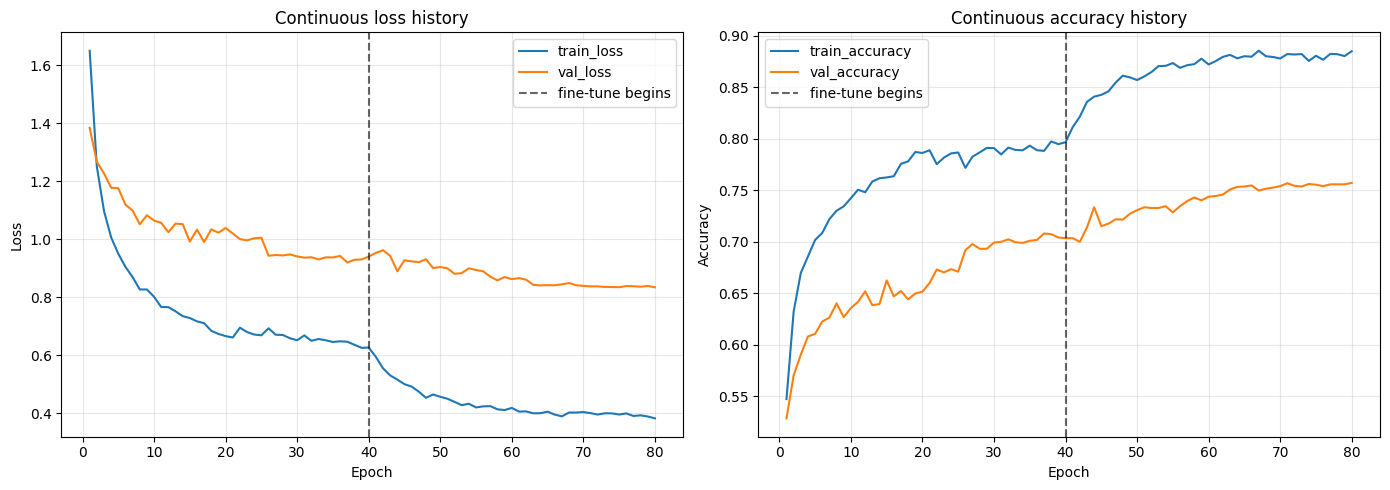

In [24]:
def merge_histories(*histories):
    merged = {}
    for hist in histories:
        for key, values in hist.history.items():
            merged.setdefault(key, []).extend(values)
    return merged
history_all = merge_histories(history_phase1, history_phase2)
epochs = np.arange(1, len(history_all.get("loss", [])) + 1)
phase_boundary = len(history_phase1.history.get("loss", []))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history_all["loss"], label="train_loss")
axes[0].plot(epochs, history_all["val_loss"], label="val_loss")
axes[0].axvline(phase_boundary, linestyle="--", color="black", alpha=0.6, label="fine-tune begins")
axes[0].set_title("Continuous loss history")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(epochs, history_all["accuracy"], label="train_accuracy")
axes[1].plot(epochs, history_all["val_accuracy"], label="val_accuracy")
axes[1].axvline(phase_boundary, linestyle="--", color="black", alpha=0.6, label="fine-tune begins")
axes[1].set_title("Continuous accuracy history")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Segment-Level Test Predictions

In [25]:
segment_probs = dl_model.predict(test_ds, verbose=1)
segment_pred = np.argmax(segment_probs, axis=1)

if len(segment_pred) != len(y_test_seg):
    raise ValueError(f"Segment prediction length mismatch: {len(segment_pred)} != {len(y_test_seg)}")

segment_acc = accuracy_score(y_test_seg, segment_pred)
print(f"Segment-level test accuracy: {segment_acc:.4f}\n")
print("--- Segment-Level Classification Report ---")
print(classification_report(y_test_seg, segment_pred, target_names=GENRE_NAMES, zero_division=0))

89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step
Segment-level test accuracy: 0.7510

--- Segment-Level Classification Report ---
              precision    recall  f1-score   support

       blues       0.82      0.74      0.77       285
   classical       0.89      0.89      0.89       285
     country       0.78      0.78      0.78       285
       disco       0.82      0.61      0.70       285
      hiphop       0.82      0.78      0.80       285
        jazz       0.75      0.82      0.79       285
       metal       0.82      0.93      0.87       266
         pop       0.66      0.73      0.69       285
      reggae       0.62      0.70      0.66       285
        rock       0.58      0.54      0.56       285

    accuracy                           0.75      2831
   macro avg       0.75      0.75      0.75      2831
weighted avg       0.75      0.75      0.75      2831



# Clip-Level Soft-Voting Probability Aggregation

In [26]:
clip_prob_map = {}
clip_true_map = {}

for prob, track_index, true_label in zip(segment_probs, test_seg_track_idx, y_test_seg):
    track_index = int(track_index)
    clip_prob_map.setdefault(track_index, []).append(prob)

    if track_index in clip_true_map and clip_true_map[track_index] != int(true_label):
        raise ValueError(f"Inconsistent ground-truth labels detected for track {track_index}")

    clip_true_map[track_index] = int(true_label)

clip_indices_sorted = sorted(clip_prob_map.keys())
clip_probs = np.stack([np.mean(clip_prob_map[idx], axis=0) for idx in clip_indices_sorted])
clip_true = np.asarray([clip_true_map[idx] for idx in clip_indices_sorted], dtype=np.int64)
clip_pred = np.argmax(clip_probs, axis=1)

final_acc = accuracy_score(clip_true, clip_pred)

clip_results = pd.DataFrame(
    {
        "track_index": clip_indices_sorted,
        "true_label": clip_true,
        "true_genre": [GENRE_NAMES[i] for i in clip_true],
        "pred_label": clip_pred,
        "pred_genre": [GENRE_NAMES[i] for i in clip_pred],
        "confidence": np.max(clip_probs, axis=1),
        "correct": clip_true == clip_pred,
    }
)

# Final Classification Report

In [27]:
print(f"\nFinal Clip-Level Soft-Voting Accuracy: {final_acc:.4f} ({final_acc * 100:.2f}%)")
print("\n--- Clip-Level Classification Report ---")
print(classification_report(clip_true, clip_pred, target_names=GENRE_NAMES, zero_division=0))
display(clip_results.head())


Final Clip-Level Soft-Voting Accuracy: 0.8255 (82.55%)

--- Clip-Level Classification Report ---
              precision    recall  f1-score   support

       blues       0.92      0.80      0.86        15
   classical       0.93      0.93      0.93        15
     country       0.81      0.87      0.84        15
       disco       0.83      0.67      0.74        15
      hiphop       0.92      0.80      0.86        15
        jazz       0.93      0.87      0.90        15
       metal       0.78      1.00      0.88        14
         pop       0.76      0.87      0.81        15
      reggae       0.69      0.73      0.71        15
        rock       0.73      0.73      0.73        15

    accuracy                           0.83       149
   macro avg       0.83      0.83      0.83       149
weighted avg       0.83      0.83      0.83       149



,track_index,true_label,true_genre,pred_label,pred_genre,confidence,correct
0,2,0,blues,9,rock,0.463402,False
1,4,0,blues,9,rock,0.460151,False
2,9,0,blues,0,blues,0.857624,True
3,12,0,blues,0,blues,0.895962,True
4,23,0,blues,0,blues,0.998832,True


# Confusion Matrices

Standard Confusion Matrix




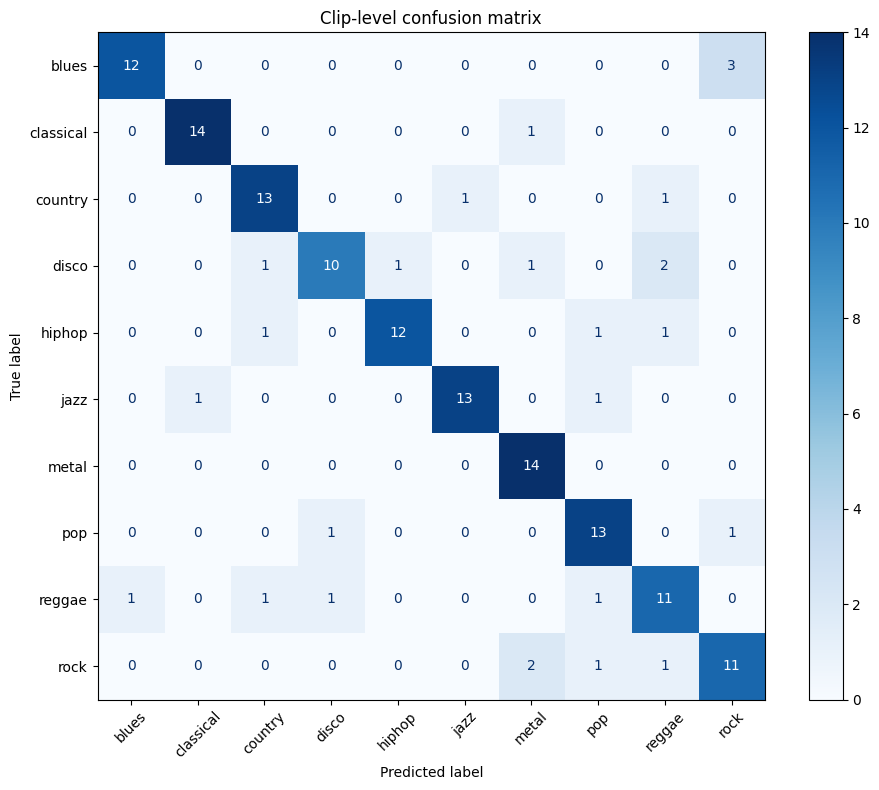

In [28]:
cm = confusion_matrix(clip_true, clip_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=GENRE_NAMES).plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title("Clip-level confusion matrix")
plt.tight_layout()
plt.show()

Normalized Confusion Matrix

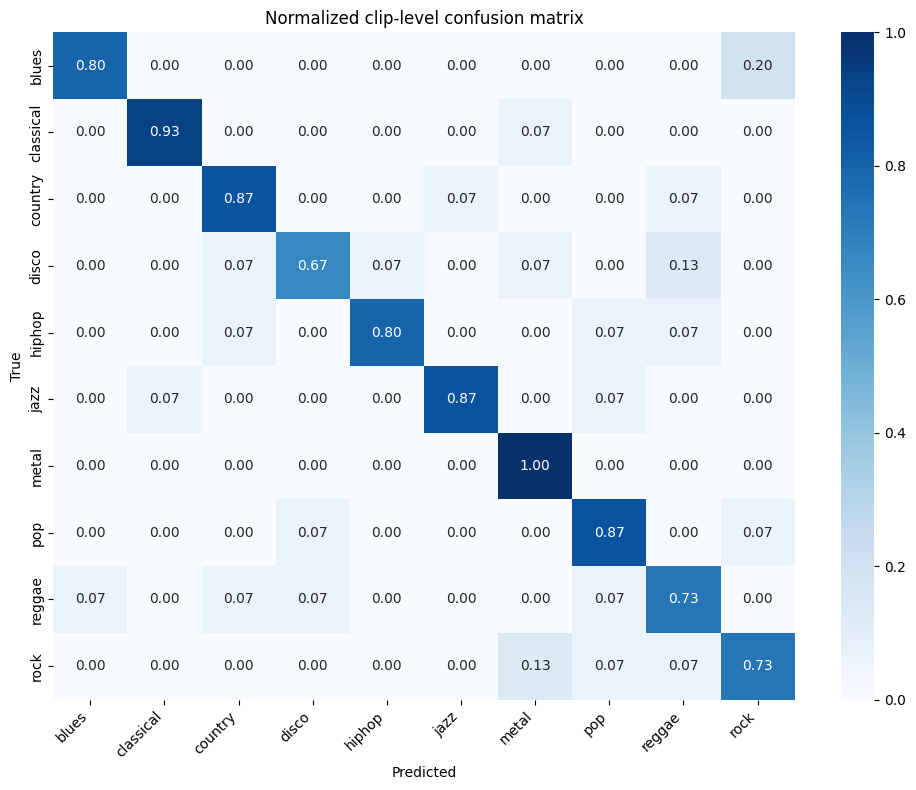

In [29]:
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=GENRE_NAMES,
    yticklabels=GENRE_NAMES,
    ax=ax,
)
ax.set_title("Normalized clip-level confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Multi-Class ROC Curves

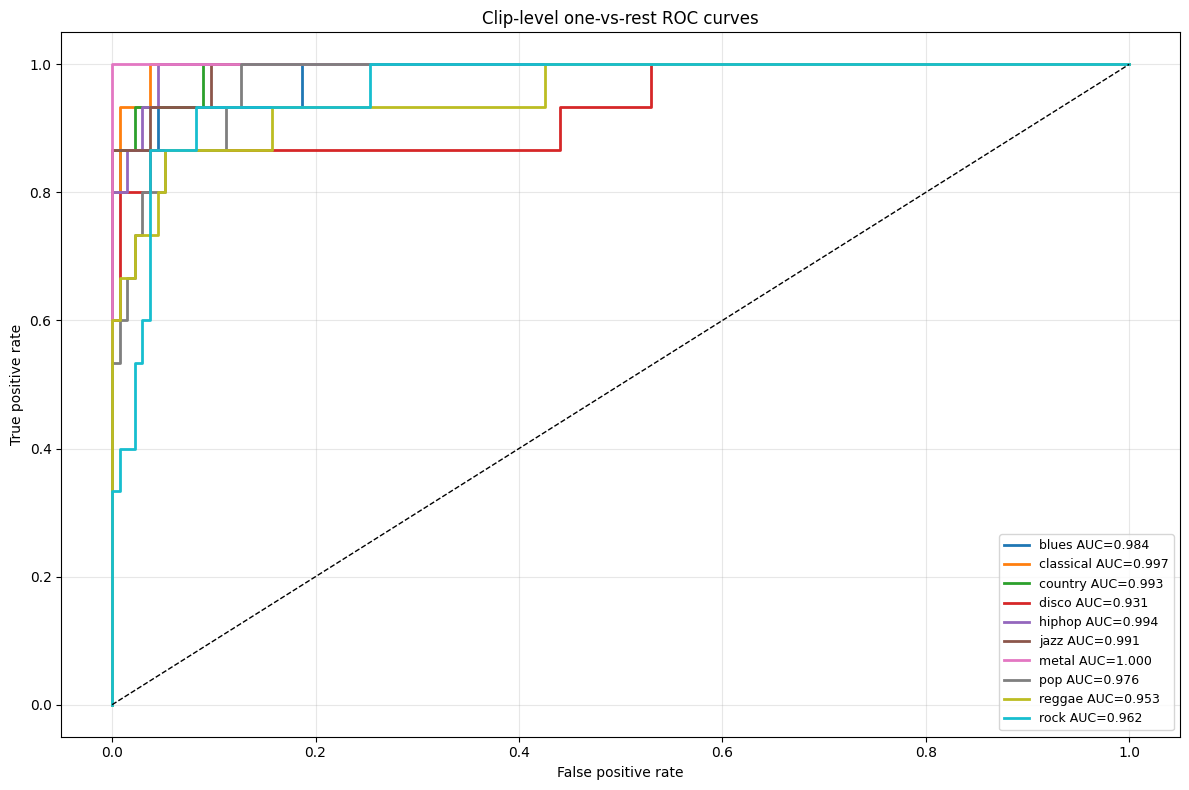

In [30]:
clip_true_bin = label_binarize(clip_true, classes=np.arange(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(12, 8))

for class_id in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(clip_true_bin[:, class_id], clip_probs[:, class_id])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{GENRE_NAMES[class_id]} AUC={roc_auc:.3f}")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Clip-level one-vs-rest ROC curves")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Self-Contained Raw-Audio Inference Function With Confidence-Scored Genre Output

In [31]:
def preprocess_audio_file_to_segments(audio_path: str) -> np.ndarray:
    audio, sr = librosa.load(audio_path, sr=None, mono=True)
    audio = np.asarray(audio, dtype=np.float32).ravel()

    if sr != CFG.SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=CFG.SAMPLE_RATE)

    if audio.size < CFG.TRACK_SAMPLES:
        audio = np.pad(audio, (0, CFG.TRACK_SAMPLES - audio.size), mode="constant")
    elif audio.size > CFG.TRACK_SAMPLES:
        audio = audio[: CFG.TRACK_SAMPLES]

    specs = []
    for start in SEGMENT_STARTS:
        start = int(start)
        end = start + CFG.SEGMENT_SAMPLES
        segment = audio[start:end]
        if len(segment) == CFG.SEGMENT_SAMPLES:
            specs.append(safe_audio_to_logmel(segment))

    if not specs:
        raise RuntimeError("No inference segments were generated from the audio file.")

    specs = np.stack(specs).astype(np.float32)
    specs = normalize_spectrogram_array(specs, "inference")
    return specs

def predict_genre(audio_path: str, model_path: str = CFG.BEST_MODEL_PATH, top_k: int = 3):
    if Path(model_path).exists():
        model = keras.models.load_model(model_path)
    else:
        model = dl_model

    specs = preprocess_audio_file_to_segments(audio_path)
    probs = model.predict(specs, batch_size=CFG.BATCH_SIZE, verbose=0)
    clip_prob = probs.mean(axis=0)

    order = np.argsort(clip_prob)[::-1][:top_k]
    result = pd.DataFrame(
        {
            "rank": np.arange(1, len(order) + 1),
            "genre": [GENRE_NAMES[i] for i in order],
            "probability": clip_prob[order],
            "confidence_percent": clip_prob[order] * 100.0,
        }
    )

    predicted_idx = int(order[0])
    output = {
        "predicted_label": predicted_idx,
        "predicted_genre": GENRE_NAMES[predicted_idx],
        "confidence": float(clip_prob[predicted_idx]),
        "top_k": result,
        "segment_count": int(len(specs)),
    }

    print(f"Predicted genre: {output['predicted_genre']} ({output['confidence']:.2%})")
    display(result)
    return output

print("Inference function ready: predict_genre('/path/to/audio.wav')")

Inference function ready: predict_genre('/path/to/audio.wav')


# Ultimate State Audit

In [32]:
required_objects = [
    "tracks",
    "labels",
    "track_hashes",
    "train_idx",
    "val_idx",
    "test_idx",
    "X_train_spec",
    "X_val_spec",
    "X_test_spec",
    "X_tab",
    "FEATURE_NAMES",
    "rf_search",
    "dl_model",
    "segment_probs",
    "segment_pred",
    "clip_probs",
    "clip_true",
    "clip_pred",
    "clip_results",
    "final_acc",
]

missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError(f"Missing required runtime objects: {missing}")

assert len(FEATURE_NAMES) == X_tab.shape[1]
assert X_tab.shape[0] == len(labels)

assert set(train_idx).isdisjoint(set(val_idx))
assert set(train_idx).isdisjoint(set(test_idx))
assert set(val_idx).isdisjoint(set(test_idx))

assert set(track_hashes[train_idx]).isdisjoint(set(track_hashes[val_idx]))
assert set(track_hashes[train_idx]).isdisjoint(set(track_hashes[test_idx]))
assert set(track_hashes[val_idx]).isdisjoint(set(track_hashes[test_idx]))

assert set(train_seg_track_idx).issubset(set(train_idx))
assert set(val_seg_track_idx).issubset(set(val_idx))
assert set(test_seg_track_idx).issubset(set(test_idx))

assert np.isfinite(X_train_spec.astype(np.float32)).all()
assert np.isfinite(X_val_spec.astype(np.float32)).all()
assert np.isfinite(X_test_spec.astype(np.float32)).all()
assert np.isfinite(X_tab).all()
assert np.isfinite(segment_probs).all()
assert np.isfinite(clip_probs).all()

assert np.std(X_train_spec.astype(np.float32)) > 1e-8
assert np.std(X_val_spec.astype(np.float32)) > 1e-8
assert np.std(X_test_spec.astype(np.float32)) > 1e-8

if len(segment_probs) != len(y_test_seg):
    raise ValueError(f"Segment prediction count mismatch: {len(segment_probs)} != {len(y_test_seg)}")

if len(clip_true) != len(test_idx):
    raise ValueError(f"Clip-level evaluation count mismatch: {len(clip_true)} != {len(test_idx)}")

recomputed_segment_pred = np.argmax(segment_probs, axis=1)
if not np.array_equal(segment_pred, recomputed_segment_pred):
    raise ValueError("segment_pred is stale relative to segment_probs.")

recomputed_clip_pred = np.argmax(clip_probs, axis=1)
if not np.array_equal(clip_pred, recomputed_clip_pred):
    raise ValueError("clip_pred is stale relative to clip_probs.")

recomputed_final_acc = accuracy_score(clip_true, clip_pred)
if not np.isclose(final_acc, recomputed_final_acc):
    raise ValueError(f"Stale final_acc detected: {final_acc} != {recomputed_final_acc}")

if not np.array_equal(
    clip_results["correct"].to_numpy(),
    (clip_results["true_label"].to_numpy() == clip_results["pred_label"].to_numpy()),
):
    raise ValueError("clip_results correctness evaluation column is stale or inconsistent.")

print("Final notebook-state audit passed with structural metric consistency checks.")
print(f"Verified final clip-level accuracy: {final_acc:.4f}")

Final notebook-state audit passed with structural metric consistency checks.
Verified final clip-level accuracy: 0.8255


#